In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import linregress

In [2]:
df = pd.read_csv("haldwani_global_product.csv")

In [73]:
df.shape

(118, 10)

In [4]:
df.columns

Index(['wkt_geom', 'LAYER', 'ID', 'h100', 'Year', 'AGB', 'GEDI_AGB', 'GEDI_SD',
       'CCI_2020_AGB', 'CCI_2020_SD'],
      dtype='str')

In [71]:
gedi_df = df[
    ["AGB", "GEDI_AGB", "GEDI_SD"]
].copy()

gedi_df = gedi_df[
    (gedi_df["GEDI_SD"]>=0)   
]

In [69]:
cci_df = df[
    ["AGB", "CCI_2020_AGB", "CCI_2020_SD"]
].copy()

cci_df = cci_df[
    (cci_df["CCI_2020_SD"] >= 0)
]

In [72]:
print(gedi_df["AGB"].shape) 
print(gedi_df["GEDI_AGB"].shape) #This is defined as the mass, expressed as oven-dry weight of the woody parts (stem, bark, branches and twigs) of all living trees excluding stump and roots
print(gedi_df["GEDI_SD"].shape) #Per-pixel estimates of above-ground biomass uncertainty expressed as the standard deviation in Mg/ha

print(cci_df["AGB"].shape)
print(cci_df["CCI_2020_AGB"].shape) 
print(cci_df["CCI_2020_SD"].shape) 

(75,)
(75,)
(75,)
(75,)
(75,)
(75,)


In [49]:
#set global font size
plt.rcParams.update({'font.size': 16})

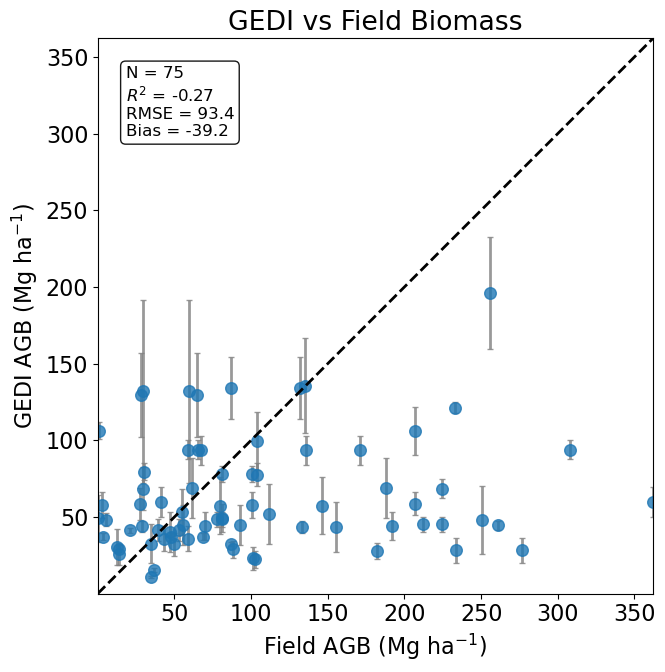

In [50]:
xmin_gedi = min(
    gedi_df["AGB"].min(),
    gedi_df["GEDI_AGB"].min()
)

xmax_gedi = max(
    gedi_df["AGB"].max(),
    gedi_df["GEDI_AGB"].max()
)

fig, ax = plt.subplots(figsize=(7,7))

ax.errorbar(
    gedi_df["AGB"],
    gedi_df["GEDI_AGB"],
    yerr=gedi_df["GEDI_SD"],
    fmt='none',
    ecolor='gray',
    alpha=0.8,
    capsize=2,
    linewidth=2,
    zorder=1
)

ax.scatter(
    gedi_df["AGB"],
    gedi_df["GEDI_AGB"],
    s=70,
    alpha=0.8,
    zorder=2
)

ax.plot(
    [xmin_gedi, xmax_gedi],
    [xmin_gedi, xmax_gedi],
    linestyle='--',
    linewidth=2,
    color='black',
    label='1:1'
)

r2_gedi = r2_score(
    gedi_df["AGB"],
    gedi_df["GEDI_AGB"]
)

rmse_gedi = np.sqrt(
    mean_squared_error(
        gedi_df["AGB"],
        gedi_df["GEDI_AGB"]
    )
)

bias_gedi = (
    gedi_df["GEDI_AGB"] -
    gedi_df["AGB"]
).mean()

ax.set_xlim(xmin_gedi, xmax_gedi)
ax.set_ylim(xmin_gedi, xmax_gedi)

ax.set_aspect('equal')

ax.set_xlabel("Field AGB (Mg ha$^{-1}$)")
ax.set_ylabel("GEDI AGB (Mg ha$^{-1}$)")
ax.set_title("GEDI vs Field Biomass")

stats_text = (
    f'N = {len(gedi_df)}\n'
    f'$R^2$ = {r2_gedi:.2f}\n'
    f'RMSE = {rmse_gedi:.1f}\n'
    f'Bias = {bias_gedi:.1f}'
)

ax.text(
    0.05,
    0.95,
    stats_text,
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        alpha=0.9
    )
)

plt.tight_layout()
plt.show()

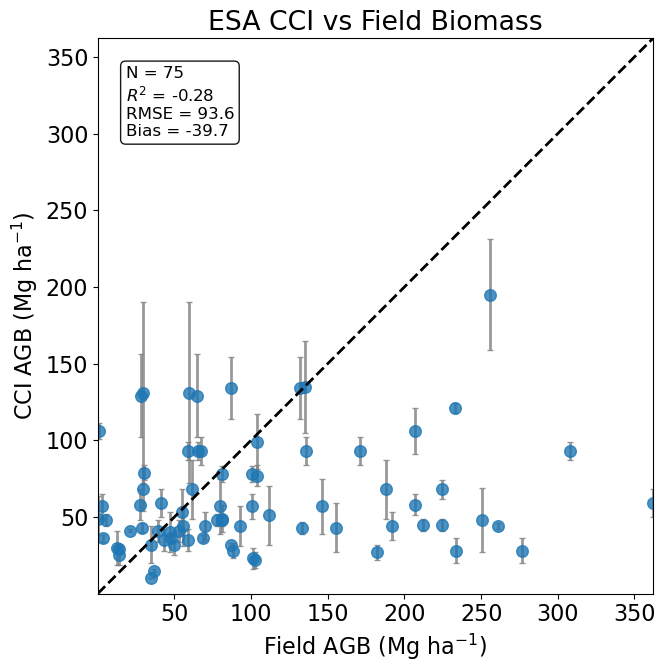

In [74]:
xmin_cci = min(
    cci_df["AGB"].min(),
    cci_df["CCI_2020_AGB"].min()
)

xmax_cci = max(
    cci_df["AGB"].max(),
    cci_df["CCI_2020_AGB"].max()
)

fig, ax = plt.subplots(figsize=(7,7))

ax.errorbar(
    cci_df["AGB"],
    cci_df["CCI_2020_AGB"],
    yerr=cci_df["CCI_2020_SD"],
    fmt='none',
    ecolor='gray',
    alpha=0.8,
    capsize=2,
    linewidth=2,
    zorder=1
)

ax.scatter(
    cci_df["AGB"],
    cci_df["CCI_2020_AGB"],
    s=70,
    alpha=0.8,
    zorder=2
)

ax.plot(
    [xmin_cci, xmax_cci],
    [xmin_cci, xmax_cci],
    linestyle='--',
    linewidth=2,
    color='black',
    label='1:1'
)

r2_cci = r2_score(
    cci_df["AGB"],
    cci_df["CCI_2020_AGB"]
)

rmse_cci = np.sqrt(
    mean_squared_error(
        cci_df["AGB"],
        cci_df["CCI_2020_AGB"]
    )
)

bias_cci = (
    cci_df["CCI_2020_AGB"] -
    cci_df["AGB"]
).mean()

ax.set_xlim(xmin_cci, xmax_cci)
ax.set_ylim(xmin_cci, xmax_cci)

ax.set_aspect('equal')

ax.set_xlabel(r'Field AGB (Mg ha$^{-1}$)')
ax.set_ylabel(r'CCI AGB (Mg ha$^{-1}$)')
ax.set_title('ESA CCI vs Field Biomass')

stats_text = (
    f'N = {len(cci_df)}\n'
    f'$R^2$ = {r2_cci:.2f}\n'
    f'RMSE = {rmse_cci:.1f}\n'
    f'Bias = {bias_cci:.1f}'
)

ax.text(
    0.05,
    0.95,
    stats_text,
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        alpha=0.9
    )
)

plt.tight_layout()
plt.show()

In [83]:
df_2015_CCI = pd.read_csv("Haldwani_2015_CCI.csv")
df_2017_CCI = pd.read_csv("Haldwani_2017_CCI.csv")
df_2018_CCI = pd.read_csv("Haldwani_2018_CCI.csv")
df_2023_CCI = pd.read_csv("Haldwani_2023_CCI_2022.csv")


df_2018_GEDI = pd.read_csv("Haldwani_2018_GEDI.csv")
df_2023_GEDI = pd.read_csv("Haldwani_2023_GEDI.csv")

df_2023_GFW_AGB = pd.read_csv("Haldwani_2023_GFW_AGB_2022.csv")
df_2023_GFW_SD = pd.read_csv("Haldwani_2023_GFW_SD_2022.csv")


In [79]:
cci_data = {
    2015: pd.read_csv("Haldwani_2015_CCI.csv"),
    2017: pd.read_csv("Haldwani_2017_CCI.csv"),
    2018: pd.read_csv("Haldwani_2018_CCI.csv"),
    2023: pd.read_csv("Haldwani_2023_CCI_2022.csv")
}

gedi_data = {
    2018: pd.read_csv("Haldwani_2018_GEDI.csv"),
    2023: pd.read_csv("Haldwani_2023_GEDI.csv")
}

gfw_agb = pd.read_csv("Haldwani_2023_GFW_AGB_2022.csv")
gfw_sd  = pd.read_csv("Haldwani_2023_GFW_SD_2022.csv")

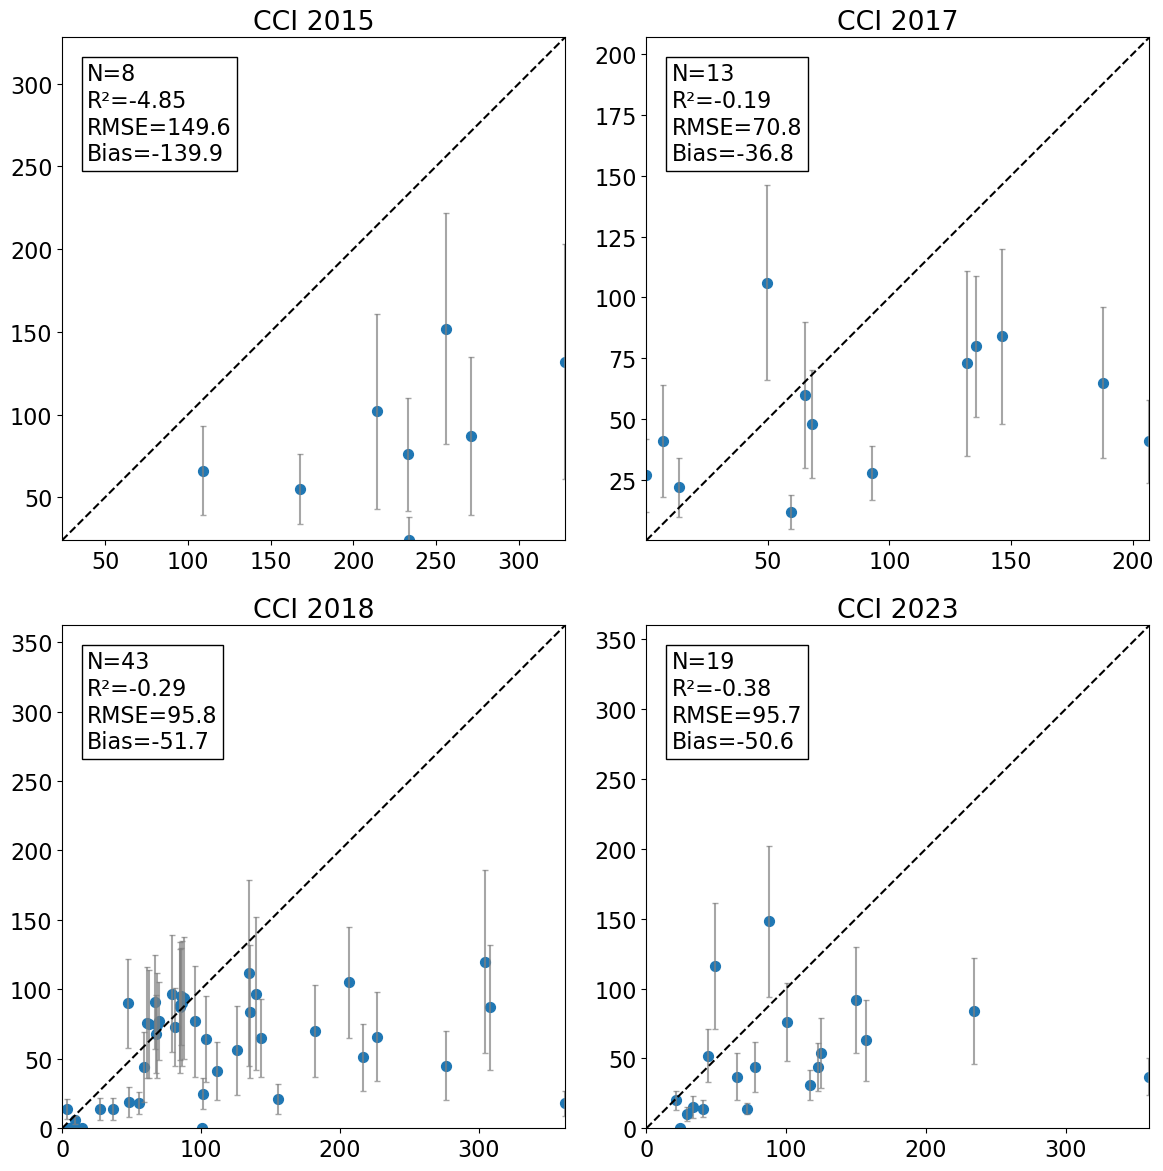

In [81]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for ax, (yr, df) in zip(axes, cci_data.items()):

    field_col = "AGB"
    pred_col  = "CCI_1"
    sd_col    = "CCI_2"

    xmin = min(df[field_col].min(), df[pred_col].min())
    xmax = max(df[field_col].max(), df[pred_col].max())

    ax.errorbar(
        df[field_col],
        df[pred_col],
        yerr=df[sd_col],
        fmt='none',
        ecolor='gray',
        alpha=0.7,
        capsize=2
    )

    ax.scatter(
        df[field_col],
        df[pred_col],
        s=50
    )

    ax.plot(
        [xmin, xmax],
        [xmin, xmax],
        '--k'
    )

    r2 = r2_score(df[field_col], df[pred_col])
    rmse = np.sqrt(mean_squared_error(df[field_col], df[pred_col]))
    bias = (df[pred_col] - df[field_col]).mean()

    ax.text(
        0.05,
        0.95,
        f'N={len(df)}\nR²={r2:.2f}\nRMSE={rmse:.1f}\nBias={bias:.1f}',
        transform=ax.transAxes,
        va='top',
        bbox=dict(facecolor='white')
    )

    ax.set_title(f'CCI {yr}')
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(xmin, xmax)
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

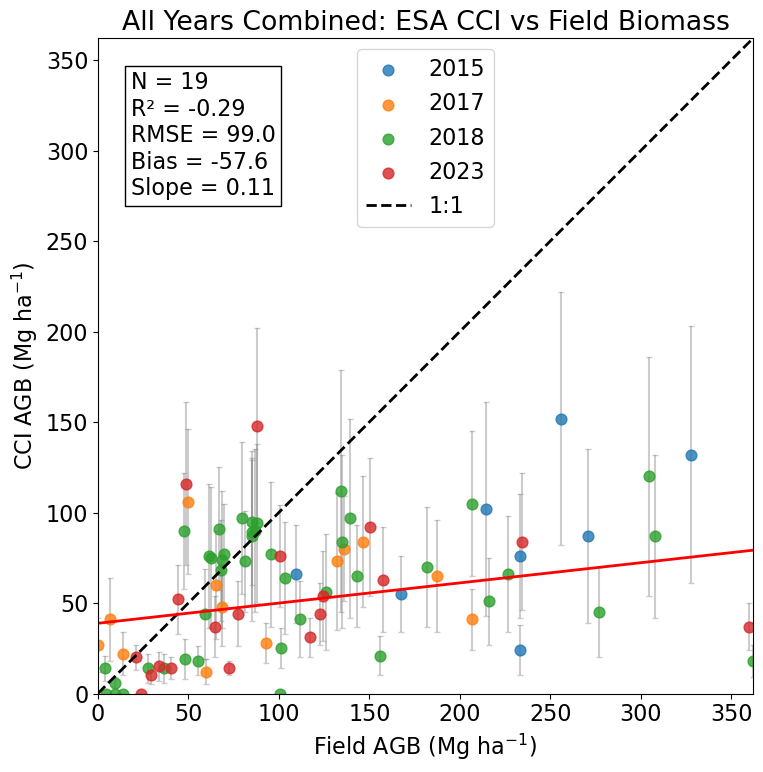

In [89]:
cci_all = pd.concat(
    [
        df_2015_CCI.assign(Year=2015),
        df_2017_CCI.assign(Year=2017),
        df_2018_CCI.assign(Year=2018),
        df_2023_CCI.assign(Year=2023)
    ],
    ignore_index=True
)

field_col = "AGB"
pred_col  = "CCI_1"
sd_col    = "CCI_2"

xmin = min(
    cci_all[field_col].min(),
    cci_all[pred_col].min()
)

xmax = max(
    cci_all[field_col].max(),
    cci_all[pred_col].max()
)

# Regression line
slope, intercept, r, p, se = linregress(
    df[field_col],
    df[pred_col]
)

fig, ax = plt.subplots(figsize=(8,8))

# Error bars
ax.errorbar(
    cci_all[field_col],
    cci_all[pred_col],
    yerr=cci_all[sd_col],
    fmt='none',
    ecolor='gray',
    alpha=0.4,
    capsize=2,
    zorder=1
)

# Points colored by year
for yr, grp in cci_all.groupby("Year"):
    ax.scatter(
        grp[field_col],
        grp[pred_col],
        s=60,
        label=str(yr),
        alpha=0.8,
        zorder=2
    )

# 1:1 line
ax.plot(
    [xmin, xmax],
    [xmin, xmax],
    '--k',
    linewidth=2,
    label='1:1'
)

r2 = r2_score(
    cci_all[field_col],
    cci_all[pred_col]
)

rmse = np.sqrt(
    mean_squared_error(
        cci_all[field_col],
        cci_all[pred_col]
    )
)

bias = (
    cci_all[pred_col] -
    cci_all[field_col]
).mean()

stats_text = (
    f'N = {len(df)}\n'
    f'R² = {r2:.2f}\n'
    f'RMSE = {rmse:.1f}\n'
    f'Bias = {bias:.1f}\n'
    f'Slope = {slope:.2f}'
)
ax.text(
    0.05,
    0.95,
    stats_text,
    transform=ax.transAxes,
    verticalalignment='top',
    bbox=dict(facecolor='white')
)

ax.set_xlim(xmin, xmax)
ax.set_ylim(xmin, xmax)
ax.set_aspect('equal')

ax.set_xlabel(r'Field AGB (Mg ha$^{-1}$)')
ax.set_ylabel(r'CCI AGB (Mg ha$^{-1}$)')
ax.set_title('All Years Combined: ESA CCI vs Field Biomass')

ax.legend()

xfit = np.linspace(xmin, xmax, 100)

ax.plot(
    xfit,
    intercept + slope*xfit,
    color='red',
    linewidth=2,
    label='Linear Fit'
)

# Mean bias
bias = (
    df[pred_col] -
    df[field_col]
).mean()

# # Bias-shifted 1:1 line
# ax.plot(
#     xfit,
#     xfit + bias,
#     color='blue',
#     linestyle=':',
#     linewidth=2,
#     label=f'1:1 + Bias ({bias:.1f})'
# )

plt.tight_layout()
plt.show()